# NLP — TF-IDF + CBOW (Tutorial 8)

In [1]:
import math
from collections import Counter

# Our sample corpus (3 documents)
docs = [
    "the cat chased the mouse",
    "the dog barked at the cat",
    "the mouse ran away from the cat"
]

# Tokenize: split each sentence into words and convert to lowercase
# This ensures 'Cat' and 'cat' are treated as the same word
tokenized = [doc.lower().split() for doc in docs]
print("Tokenized documents:")
for i, doc in enumerate(tokenized):
    print(f"  Doc {i+1}:", doc)

Tokenized documents:
  Doc 1: ['the', 'cat', 'chased', 'the', 'mouse']
  Doc 2: ['the', 'dog', 'barked', 'at', 'the', 'cat']
  Doc 3: ['the', 'mouse', 'ran', 'away', 'from', 'the', 'cat']


In [2]:
# Build vocabulary: all unique words across all documents, sorted alphabetically
# Using a set ensures no duplicates
vocab = sorted(set(word for doc in tokenized for word in doc))
print("Vocabulary:", vocab)
print("Vocabulary size:", len(vocab))

Vocabulary: ['at', 'away', 'barked', 'cat', 'chased', 'dog', 'from', 'mouse', 'ran', 'the']
Vocabulary size: 10


In [3]:
# Calculate TF (Term Frequency) for each document
# TF(word, doc) = count of word in doc / total words in doc
# Normalizing by document length avoids bias toward longer documents

tf = []
for doc in tokenized:
    count = Counter(doc)       # Count occurrences of each word
    total = len(doc)           # Total words in this document
    tf.append({word: count[word] / total for word in vocab})

print("TF values (Term Frequency):")
for i, doc_tf in enumerate(tf):
    # Only show non-zero values for clarity
    nonzero = {w: round(v, 4) for w, v in doc_tf.items() if v > 0}
    print(f"  Doc {i+1}:", nonzero)

TF values (Term Frequency):
  Doc 1: {'cat': 0.2, 'chased': 0.2, 'mouse': 0.2, 'the': 0.4}
  Doc 2: {'at': 0.1667, 'barked': 0.1667, 'cat': 0.1667, 'dog': 0.1667, 'the': 0.3333}
  Doc 3: {'away': 0.1429, 'cat': 0.1429, 'from': 0.1429, 'mouse': 0.1429, 'ran': 0.1429, 'the': 0.2857}


In [4]:
# Calculate IDF (Inverse Document Frequency)
# IDF(word) = log10(N / (1 + df)) where df = number of docs containing the word
# Words that appear in ALL documents get low IDF (they are not distinctive)
# Words in only 1 document get high IDF (they are distinctive)

N = len(tokenized)  # Total number of documents
idf = {}
for word in vocab:
    df = sum(1 for doc in tokenized if word in doc)  # Document frequency
    idf[word] = math.log10(N / (1 + df))             # +1 avoids division by zero

print("IDF values (Inverse Document Frequency):")
for word, val in idf.items():
    print(f"  '{word}': {round(val, 4)}")

IDF values (Inverse Document Frequency):
  'at': 0.1761
  'away': 0.1761
  'barked': 0.1761
  'cat': -0.1249
  'chased': 0.1761
  'dog': 0.1761
  'from': 0.1761
  'mouse': 0.0
  'ran': 0.1761
  'the': -0.1249


In [5]:
# Calculate TF-IDF = TF * IDF
# High TF-IDF = word appears often in THIS doc but rarely in others → distinctive!

tfidf = []
for doc_tf in tf:
    tfidf.append({word: round(doc_tf[word] * idf[word], 4) for word in vocab})

print("TF-IDF values:")
for i, doc_tfidf in enumerate(tfidf):
    nonzero = {w: v for w, v in doc_tfidf.items() if v > 0}
    print(f"  Doc {i+1}:", nonzero)

TF-IDF values:
  Doc 1: {'chased': 0.0352}
  Doc 2: {'at': 0.0293, 'barked': 0.0293, 'dog': 0.0293}
  Doc 3: {'away': 0.0252, 'from': 0.0252, 'ran': 0.0252}


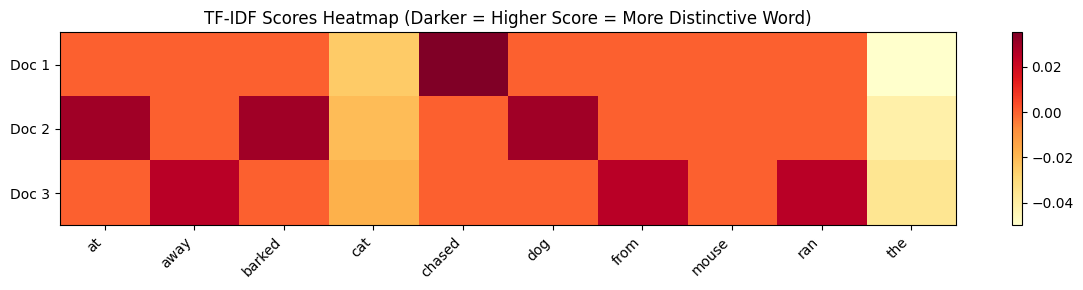

In [6]:
# Visualize TF-IDF as a heatmap
import numpy as np
import matplotlib.pyplot as plt

matrix = np.array([[doc[word] for word in vocab] for doc in tfidf])

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(vocab)))
ax.set_xticklabels(vocab, rotation=45, ha='right')
ax.set_yticks(range(3))
ax.set_yticklabels(['Doc 1', 'Doc 2', 'Doc 3'])
plt.colorbar(im)
plt.title('TF-IDF Scores Heatmap (Darker = Higher Score = More Distinctive Word)')
plt.tight_layout()
plt.show()

In [7]:
# --- CBOW (Continuous Bag of Words) ---
# CBOW: Given context words around a target, predict the target word
# Here we manually generate (context, target) pairs with window_size=1

def generate_cbow_pairs(tokenized_docs, window_size=1):
    """
    For each word in a sentence, collect surrounding words as context.
    window_size=1 means 1 word to the left and 1 to the right.
    Returns list of (context_words, target_word) tuples.
    """
    pairs = []
    for doc in tokenized_docs:
        for i, target in enumerate(doc):
            context = []
            # Collect context words within window
            for j in range(i - window_size, i + window_size + 1):
                if j != i and 0 <= j < len(doc):
                    context.append(doc[j])
            if context:
                pairs.append((context, target))
    return pairs

cbow_pairs = generate_cbow_pairs(tokenized, window_size=1)
print("CBOW Training Pairs (context → target):")
for ctx, tgt in cbow_pairs[:10]:
    print(f"  Context: {ctx}  →  Target: '{tgt}'")

CBOW Training Pairs (context → target):
  Context: ['cat']  →  Target: 'the'
  Context: ['the', 'chased']  →  Target: 'cat'
  Context: ['cat', 'the']  →  Target: 'chased'
  Context: ['chased', 'mouse']  →  Target: 'the'
  Context: ['the']  →  Target: 'mouse'
  Context: ['dog']  →  Target: 'the'
  Context: ['the', 'barked']  →  Target: 'dog'
  Context: ['dog', 'at']  →  Target: 'barked'
  Context: ['barked', 'the']  →  Target: 'at'
  Context: ['at', 'cat']  →  Target: 'the'
